## INLAB

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

# Extract standard continuous features
X_pima = pima_df[pima_cols[:-1]]
y_pima = pima_df['Outcome']

print("Pima Dataset Shape (rows, cols):(24EU02022)", pima_df.shape)
print("\nClass Outcome Distribution:(24EU02022)")
print(pima_df['Outcome'].value_counts())


Pima Dataset Shape (rows, cols):(24EU02022) (768, 9)

Class Outcome Distribution:(24EU02022)
Outcome
0    500
1    268
Name: count, dtype: int64


## SubTask1.2

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Perform Stratified Train-Test Split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

# Train a baseline Random Forest Classifier
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_p, y_train_p)

# Evaluate holdout test accuracy
holdout_preds = rf_baseline.predict(X_test_p)
holdout_accuracy = accuracy_score(y_test_p, holdout_preds)

print(f"Stratified Holdout (Train-Test Split) Accuracy:(24EU02022) {holdout_accuracy * 100:.2f}%")


Stratified Holdout (Train-Test Split) Accuracy:(24EU02022) 75.97%


## SubTask1.3

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize 10-Fold Stratified CV Strategy
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Compute cross-validation scores using baseline Random Forest
cv_scores = cross_val_score(rf_baseline, X_pima, y_pima, cv=cv_strategy, scoring='accuracy')

print("10-Fold Stratified CV Accuracy Scores:(24EU02022)")
print(cv_scores.round(4))
print(f"\nMean Cross-Validation Accuracy Score:(24EU02022) {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation of CV Accuracy:(24EU02022)     {cv_scores.std() * 100:.2f}%")


10-Fold Stratified CV Accuracy Scores:(24EU02022)
[0.8052 0.7532 0.7143 0.8701 0.7922 0.7273 0.7532 0.7662 0.7895 0.7237]

Mean Cross-Validation Accuracy Score:(24EU02022) 76.95%
Standard Deviation of CV Accuracy:(24EU02022)     4.45%


## SubTask1.4

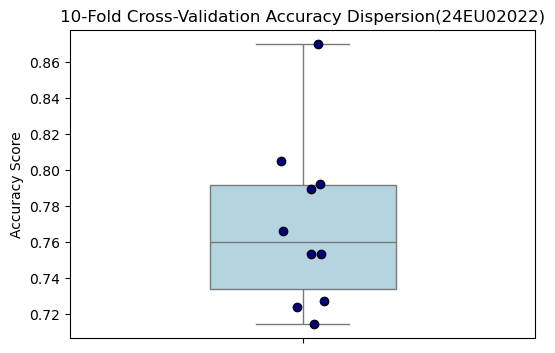

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot cross-validation score dispersion
plt.figure(figsize=(6, 4))
sns.boxplot(y=cv_scores, color='lightblue', width=0.4)
sns.stripplot(y=cv_scores, color='darkblue', size=6, jitter=0.05, edgecolor='black', linewidth=1)
plt.title("10-Fold Cross-Validation Accuracy Dispersion(24EU02022)")
plt.ylabel("Accuracy Score")
plt.show()


## SubTask1.5

In [6]:
# Compile comparison table
validation_comparison = pd.DataFrame({
    'Validation Strategy': ['Holdout Stratified (80/20 Split)', '10-Fold Stratified Cross-Validation (Mean)'],
    'Accuracy Score (%)': [holdout_accuracy * 100, cv_scores.mean() * 100],
    'Score Std Deviation (%)': [0.0, cv_scores.std() * 100]
})

print("--- Validation Strategy Trade-offs(24EU02022) ---")
print(validation_comparison.to_string(index=False))


--- Validation Strategy Trade-offs(24EU02022) ---
                       Validation Strategy  Accuracy Score (%)  Score Std Deviation (%)
          Holdout Stratified (80/20 Split)           75.974026                 0.000000
10-Fold Stratified Cross-Validation (Mean)           76.949761                 4.448026


### Task2

## SubTask2.1

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:(24EU02022)", X_train_s.shape)
print("Sonar Test Set Shape:(24EU02022)", X_test_s.shape)



Sonar Training Set Shape:(24EU02022) (145, 60)
Sonar Test Set Shape:(24EU02022) (63, 60)


## SubTask2.2

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train baseline SVM classifier with default settings
svm_default = SVC(probability=True, random_state=42)
svm_default.fit(X_train_s, y_train_s)

# Evaluate baseline accuracy
default_preds = svm_default.predict(X_test_s)
default_accuracy = accuracy_score(y_test_s, default_preds)

print(f"Default SVM Test Accuracy:(24EU02022) {default_accuracy * 100:.2f}%")


Default SVM Test Accuracy:(24EU02022) 84.13%


## SubTask2.3

In [9]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

# Run Grid Search Cross-Validation
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_s, y_train_s)

# Extract optimized model and predict
best_svm_grid = grid_search.best_estimator_
grid_preds = best_svm_grid.predict(X_test_s)
grid_accuracy = accuracy_score(y_test_s, grid_preds)

print("Optimal Hyperparameters Selected via Grid Search:(24EU02022)", grid_search.best_params_)
print(f"Grid-Search Optimized SVM Test Accuracy:(24EU02022) {grid_accuracy * 100:.2f}%")


Optimal Hyperparameters Selected via Grid Search:(24EU02022) {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Grid-Search Optimized SVM Test Accuracy:(24EU02022) 92.06%


## SubTask2.4

In [10]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions
param_distributions = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

# Run Randomized Search Cross-Validation (evaluating 10 random candidates)
random_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_s, y_train_s)

# Extract optimized model and predict
best_svm_random = random_search.best_estimator_
random_preds = best_svm_random.predict(X_test_s)
random_accuracy = accuracy_score(y_test_s, random_preds)

print("Optimal Hyperparameters Selected via Randomized Search:(24EU02022)", random_search.best_params_)
print(f"Randomized-Search Optimized SVM Test Accuracy:(24EU02022) {random_accuracy * 100:.2f}%")


Optimal Hyperparameters Selected via Randomized Search:(24EU02022) {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}
Randomized-Search Optimized SVM Test Accuracy:(24EU02022) 79.37%


## SubTask2.5

--- Hyperparameter Optimization Comparison(24EU02022) ---
                Tuning Strategy  Test Accuracy (%)
         Default Parameters SVM          84.126984
      Grid-Search Optimized SVM          92.063492
Randomized-Search Optimized SVM          79.365079


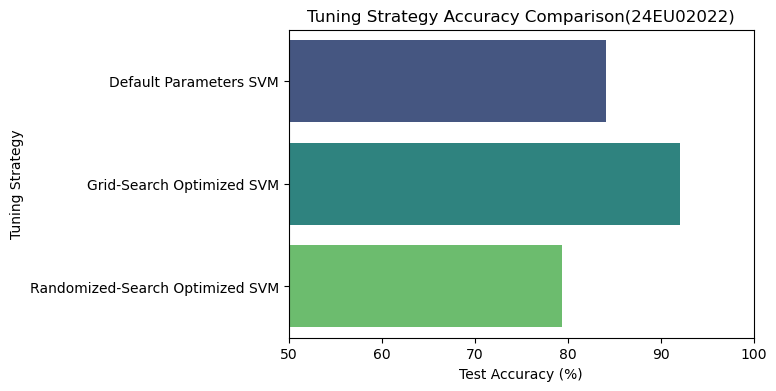

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compile results
optimization_results = pd.DataFrame({
    'Tuning Strategy': ['Default Parameters SVM', 'Grid-Search Optimized SVM', 'Randomized-Search Optimized SVM'],
    'Test Accuracy (%)': [default_accuracy * 100, grid_accuracy * 100, random_accuracy * 100]
})

print("--- Hyperparameter Optimization Comparison(24EU02022) ---")
print(optimization_results.to_string(index=False))

# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=optimization_results, x='Test Accuracy (%)', y='Tuning Strategy', palette='viridis')
plt.xlim([50, 100])
plt.title("Tuning Strategy Accuracy Comparison(24EU02022)")
plt.show()


### Task-3

## SubTask3.1

In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Reload the raw Pima Indians dataset with invalid zero entries intact
pima_raw_df = pd.read_csv(pima_url, header=None, names=pima_cols)

# Using .copy() prevents standard Pandas SettingWithCopyWarnings
X_raw_p = pima_raw_df[pima_cols[:-1]].copy()
y_raw_p = pima_raw_df['Outcome']

# Mark invalid zeros as NaN placeholders for pipeline imputation
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_raw_p[cols_to_impute] = X_raw_p[cols_to_impute].replace(0, np.nan)

# Stratified Train-Test Split (80% train, 20% test)
X_train_raw_p, X_test_raw_p, y_train_raw_p, y_test_raw_p = train_test_split(
    X_raw_p, y_raw_p, test_size=0.20, stratify=y_raw_p, random_state=42
)

# Construct Pipeline with class_weight='balanced' to handle minority class penalty
ml_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42)) 
])

print("Cost-sensitive balanced Pipeline constructed successfully.(24EU02022)")

Cost-sensitive balanced Pipeline constructed successfully.(24EU02022)


## SubTask3.2

In [13]:
from sklearn.model_selection import GridSearchCV

# We search through a range of parameters to find the optimal decision boundary
pipeline_param_grid = {
    'imputer__strategy': ['mean', 'median'],          
    'classifier__C': [0.1, 1, 5, 10, 50],               
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1] 
}

# Run Grid Search over the pipeline object
pipeline_cv = GridSearchCV(estimator=ml_pipeline, param_grid=pipeline_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
pipeline_cv.fit(X_train_raw_p, y_train_raw_p)

# Extract optimized pipeline model
best_pipeline = pipeline_cv.best_estimator_

print("Optimal Pipeline Hyperparameters Selected:(24EU02022)")
print(pipeline_cv.best_params_)

Optimal Pipeline Hyperparameters Selected:(24EU02022)
{'classifier__C': 1, 'classifier__gamma': 0.01, 'imputer__strategy': 'median'}


## SubTask3.3

End-to-End Pipeline Test Accuracy: 74.03%\n
--- Classification Report (Observe the improved Class 1 metrics) (24EU02022)---
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



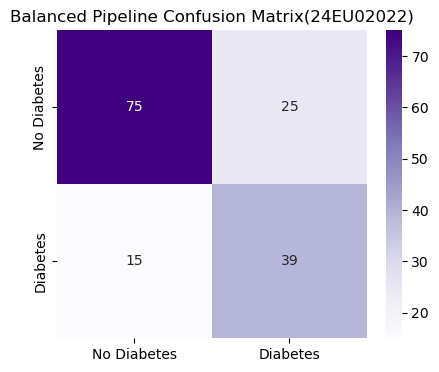

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate test predictions directly from raw data
pipeline_preds = best_pipeline.predict(X_test_raw_p)
pipeline_accuracy = accuracy_score(y_test_raw_p, pipeline_preds)

print(f"End-to-End Pipeline Test Accuracy: {pipeline_accuracy * 100:.2f}%\\n")
print("--- Classification Report (Observe the improved Class 1 metrics) (24EU02022)---")
print(classification_report(y_test_raw_p, pipeline_preds))

# Plot confusion matrix
cm_pipeline = confusion_matrix(y_test_raw_p, pipeline_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Purples', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Balanced Pipeline Confusion Matrix(24EU02022)")
plt.show()

## SubTask 3.4

In [15]:
import joblib

# Serialize pipeline object to disk
saved_filename = "pima_diabetes_pipeline.joblib"
joblib.dump(best_pipeline, saved_filename)

print(f"End-to-End Pipeline successfully serialized and saved to '{saved_filename}'.")


End-to-End Pipeline successfully serialized and saved to 'pima_diabetes_pipeline.joblib'.


## SubTask 3.5

In [16]:
# Load pipeline back from disk
deployed_pipeline = joblib.load(saved_filename)

# Mock raw patient record containing missing entries marked as 0 (invalid SkinThickness & Insulin)
raw_patient_record = pd.DataFrame([{
    'Pregnancies': 1,
    'Glucose': 189,
    'BloodPressure': 60,
    'SkinThickness': 0, # Invalid zero: will be converted to NaN and imputed by the pipeline
    'Insulin': 0,       # Invalid zero: will be converted to NaN and imputed by the pipeline
    'BMI': 30.1,
    'DiabetesPedigreeFunction': 0.398,
    'Age': 59
}])

# Convert invalid zeros to NaN for proper imputation
raw_patient_record[cols_to_impute] = raw_patient_record[cols_to_impute].replace(0, np.nan)

# Predict using the re-loaded pipeline
deployed_pred = deployed_pipeline.predict(raw_patient_record)
deployed_probs = deployed_pipeline.predict_proba(raw_patient_record)

print("Deployed Pipeline Prediction Output:(24EU02022)")
print("Predicted Class Label (0 = No Diabetes, 1 = Diabetes):", deployed_pred[0])
print(f"Probability of Diabetes Class: {deployed_probs[0][1]*100:.2f}%")


Deployed Pipeline Prediction Output:(24EU02022)
Predicted Class Label (0 = No Diabetes, 1 = Diabetes): 1
Probability of Diabetes Class: 77.00%
